# **Iris Flower Classification**

### **CodeAlpha Data Science Internship - Task 1**

**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Machine Learning


## 📌 Project Objective

The objective of this project is to classify Iris flowers into different species based on their sepal and petal measurements using Machine Learning techniques.

## Step 1: Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, machine learning model development, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Step 2: Load the Iris Dataset

The Iris dataset is loaded from the Scikit-learn library and converted into a Pandas DataFrame for analysis.

In [ ]:
# Load Dataset

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 3: Dataset Overview

The first few records of the dataset are displayed to understand the structure, features, and target labels.

In [ ]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Step 4: Data Exploration

The dataset is explored using descriptive statistics and information summaries to understand feature distributions and data quality.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
df["species"].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


## Species Distribution Analysis

A count plot is used to visualize the distribution of Iris flower species in the dataset.

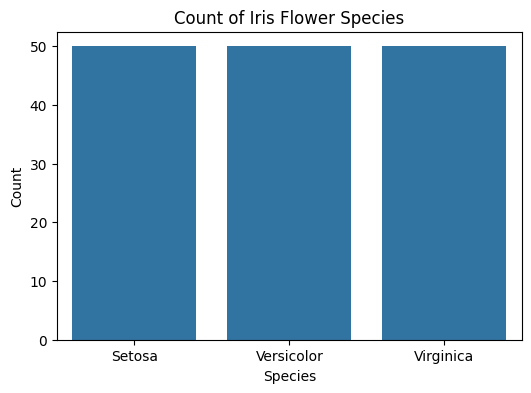

In [ ]:
# Count Plot

plt.figure(figsize=(6,4))

sns.countplot(x="species", data=df)

plt.title("Count of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## Pairwise Feature Analysis

A pair plot is generated to visualize relationships between features and identify patterns among different Iris species.

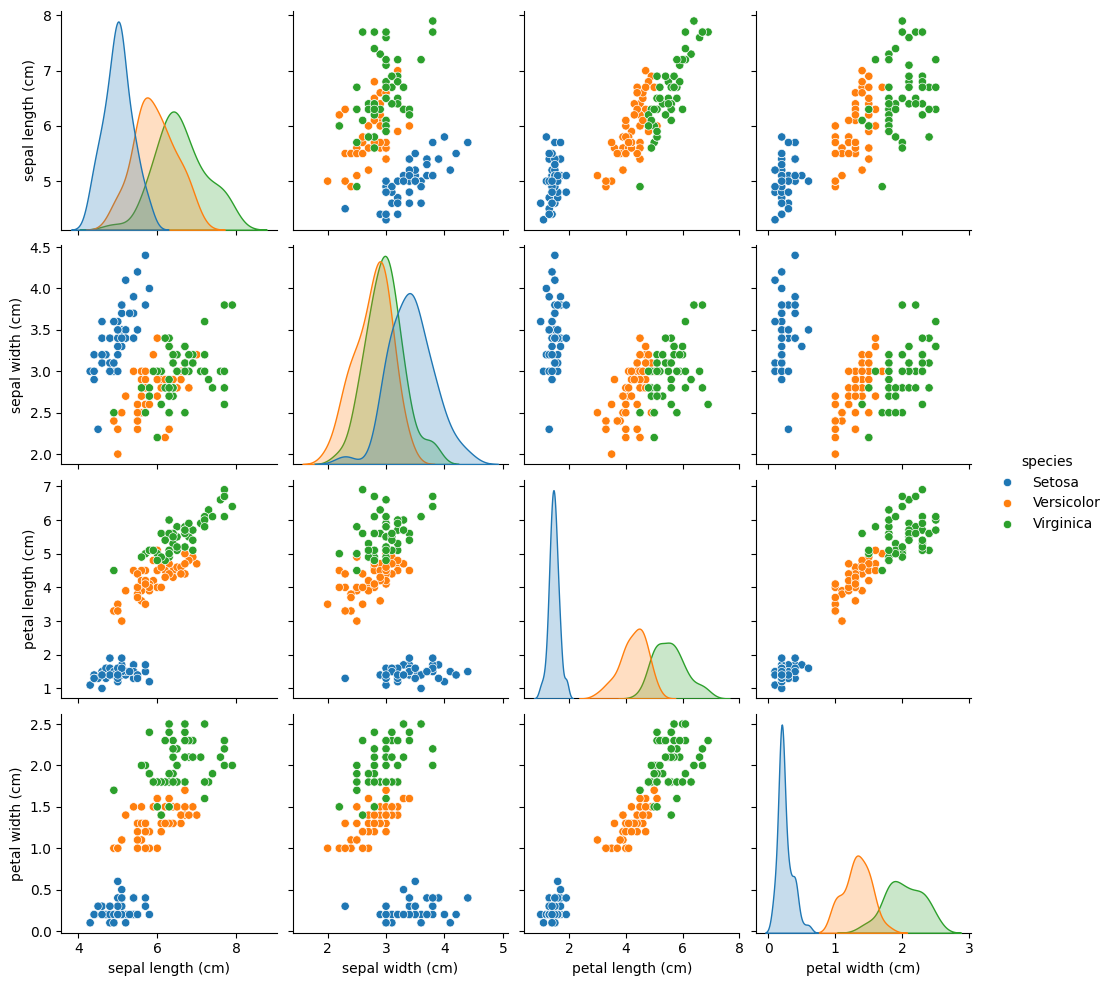

In [ ]:
# Pair Plot

sns.pairplot(df, hue="species")

plt.show()

## Correlation Analysis

A correlation heatmap is used to identify relationships between numerical features and understand feature dependencies.

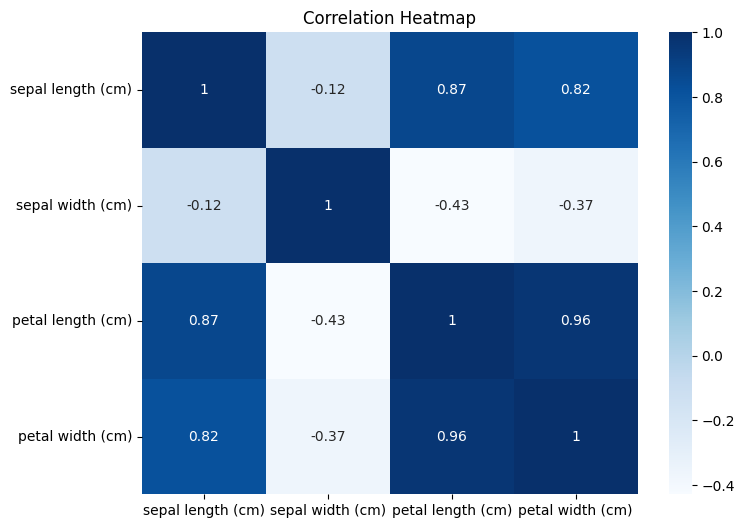

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

## Feature Selection

The input features are selected as independent variables, while the species column is selected as the target variable.

In [ ]:
# Features and Target

X = df.drop("species", axis=1)

y = df["species"]

## Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of the machine learning model on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Decision Tree Classifier is trained using the training dataset to learn patterns and classify Iris flower species.

In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Model Prediction

The trained model is used to predict flower species for the testing dataset.

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the model is evaluated using Accuracy Score, Classification Report, and Confusion Matrix.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



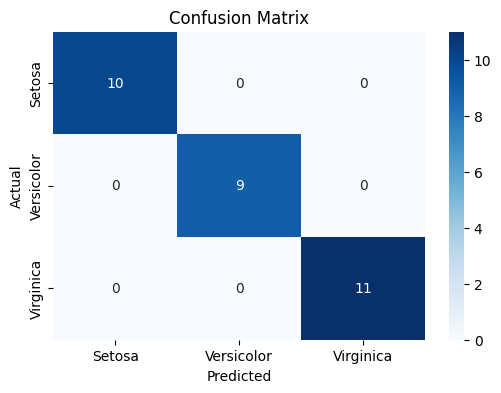

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Testing with New Sample Data

The trained model is tested using new flower measurements to predict the corresponding Iris species.

In [ ]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Model Saving

The trained machine learning model is saved for future use and deployment.

In [ ]:
import joblib

joblib.dump(model, "iris_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



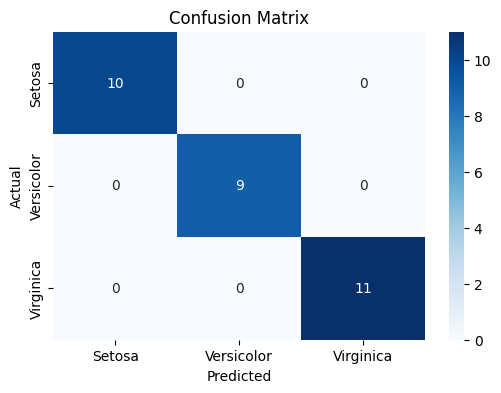

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# 📌 Conclusion

The Iris Flower Classification model was successfully developed using Machine Learning techniques.

The Decision Tree Classifier achieved excellent classification performance and accurately identified Iris flower species based on sepal and petal measurements.

The project demonstrates the effectiveness of machine learning in solving multiclass classification problems and highlights the importance of feature analysis and model evaluation.